Практическая работа №4: Решение уравнений методом хорд и касательных

задание 1

Интервалы отделения корней:
Корень найден в интервале: [-1.47, -1.37]
Корень найден в интервале: [0.57, 0.67]


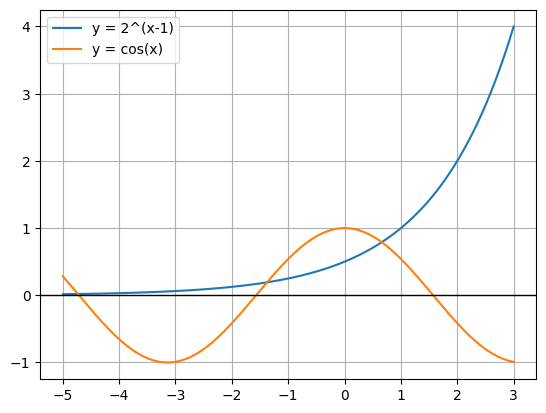

In [1]:
from numpy import *
import pandas as pd

# Исходная функция
def f(x):
    return 2**(x-1) - cos(x)

# Создаем данные для анализа
x_vals = linspace(-3, 2, 50)
y_vals = f(x_vals)

# Таблица для визуального контроля смены знаков
df = pd.DataFrame({'x': x_vals, 'f(x)': y_vals})

# Вывод только тех участков, где функция меняет знак
print("Интервалы отделения корней:")
for i in range(len(df) - 1):
    if df['f(x)'][i] * df['f(x)'][i+1] < 0:
        a = df['x'][i]
        b = df['x'][i+1]
        print(f"Корень найден в интервале: [{a:.2f}, {b:.2f}]")

# Построение графиков для отчета
import matplotlib.pyplot as plt
x_plt = linspace(-5, 3, 200)
plt.plot(x_plt, 2**(x_plt-1), label='y = 2^(x-1)')
plt.plot(x_plt, cos(x_plt), label='y = cos(x)')
plt.axhline(0, color='black', lw=1)
plt.grid(True)
plt.legend()
plt.show()

задание 2:

In [2]:
from numpy import *
import pandas as pd

# 1. Исходная функция
def f(x):
    return 2**x - 2 * cos(x)

# 2. Производная функции
def df(x):
    return 2**x * log(2) + 2 * sin(x)

def newton_method(x0, eps, max_iter=100):
    history = []
    x_curr = x0
    
    for n in range(max_iter):
        fx = f(x_curr)
        dfx = df(x_curr)
        
        # Формула Ньютона: x_{n+1} = x_n - f(x_n) / f'(x_n)
        x_next = x_curr - fx / dfx
        diff = abs(x_next - x_curr)
        
        # Сохраняем данные для таблицы
        history.append({
            'n': n + 1,
            'x_n': round(x_curr, 6),
            'f(x_n)': round(fx, 6),
            'f\'(x_n)': round(dfx, 6),
            '|x_n+1 - x_n|': round(diff, 6)
        })

        if diff < eps:
            break
        x_curr = x_next

    # Вывод таблицы через Pandas
    df_res = pd.DataFrame(history)
    print("Таблица итераций (Метод касательных / Ньютона):")
    print(df_res.to_string(index=False))
    
    print("-" * 60)
    print(f"Результат:")
    print(f"Корень x = {x_curr:.6f}")
    print(f"Значение f(x) = {f(x_curr):.6f}")
    print(f"Число итераций: {len(history)}")
    
    return x_curr

# Запуск метода
# Выбираем x0 = 1.0, так как f(1)*f''(1) > 0 (условие сходимости)
x_start = 1.0
precision = 0.001
root = newton_method(x_start, precision)

Таблица итераций (Метод касательных / Ньютона):
 n      x_n   f(x_n)  f'(x_n)  |x_n+1 - x_n|
 1 1.000000 0.919395 3.069236       0.299552
 2 0.700448 0.095903 2.415492       0.039703
 3 0.660745 0.001828 2.323206       0.000787
------------------------------------------------------------
Результат:
Корень x = 0.660745
Значение f(x) = 0.001828
Число итераций: 3


задание 3

In [3]:


# 1. Исходная функция
def f(x):
    return 2**x - 2 * cos(x)

def chord_method(a, b, eps, max_iter=100):
    history = []
    # Фиксируем правую границу b, так как f(b) * f''(b) > 0
    x_fixed = b
    x_curr = a
    
    for n in range(max_iter):
        fx_curr = f(x_curr)
        fx_fixed = f(x_fixed)
        
        # Формула метода хорд: x_{n+1} = x_n - f(x_n) * (x_fixed - x_n) / (f(x_fixed) - f(x_n))
        x_next = x_curr - fx_curr * (x_fixed - x_curr) / (fx_fixed - fx_curr)
        diff = abs(x_next - x_curr)
        
        # Сохраняем данные для таблицы
        history.append({
            'n': n + 1,
            'x_n': round(x_curr, 6),
            'f(x_n)': round(fx_curr, 6),
            '|x_n+1 - x_n|': round(diff, 6)
        })

        if diff < eps:
            break
        x_curr = x_next

    # Вывод таблицы через Pandas
    df_res = pd.DataFrame(history)
    print("Таблица итераций (Метод хорд):")
    print(df_res.to_string(index=False))
    
    print("-" * 60)
    print(f"Результат:")
    print(f"Корень x = {x_next:.6f}")
    print(f"Значение f(x) = {f(x_next):.6f}")
    print(f"Число итераций: {len(history)}")
    
    return x_next

# Запуск метода
a_start, b_start = 0.0, 1.0
precision = 0.001
root = chord_method(a_start, b_start, precision)

Таблица итераций (Метод хорд):
 n      x_n    f(x_n)  |x_n+1 - x_n|
 1 0.000000 -1.000000       0.520997
 2 0.520997 -0.299699       0.117757
 3 0.638754 -0.048694       0.018170
 4 0.656925 -0.007030       0.002603
 5 0.659528 -0.000997       0.000369
------------------------------------------------------------
Результат:
Корень x = 0.659897
Значение f(x) = -0.000141
Число итераций: 5
